In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import seaborn as sns

In [2]:
# load csv
file_path = "/home/kevin/Desktop/gut_microbiome/dataset/mgnify_gut/mgnify_raw/combined_taxonomy_abundance.csv"
df = pd.read_csv(file_path)

In [3]:
df.columns

Index(['sample_id', 'sk__Archaea', 'sk__Archaea;k__;p__Crenarchaeota',
       'sk__Archaea;k__;p__Euryarchaeota',
       'sk__Archaea;k__;p__Euryarchaeota;c__;o__;f__;g__;s__methanogenic_archaeon_CH1270',
       'sk__Archaea;k__;p__Euryarchaeota;c__Methanobacteria;o__Methanobacteriales',
       'sk__Archaea;k__;p__Euryarchaeota;c__Methanobacteria;o__Methanobacteriales;f__Methanobacteriaceae',
       'sk__Archaea;k__;p__Euryarchaeota;c__Methanobacteria;o__Methanobacteriales;f__Methanobacteriaceae;g__Methanobacterium',
       'sk__Archaea;k__;p__Euryarchaeota;c__Methanobacteria;o__Methanobacteriales;f__Methanobacteriaceae;g__Methanobrevibacter',
       'sk__Archaea;k__;p__Euryarchaeota;c__Methanobacteria;o__Methanobacteriales;f__Methanobacteriaceae;g__Methanobrevibacter;s__Methanobrevibacter_smithii',
       ...
       'sk__Bacteria;k__;p__Proteobacteria;c__Alphaproteobacteria;o__Rhizobiales;f__Brucellaceae;g__Ochrobactrum;s__Ochrobactrum_sp._Pb4',
       'sk__Bacteria;k__;p__Proteobacte

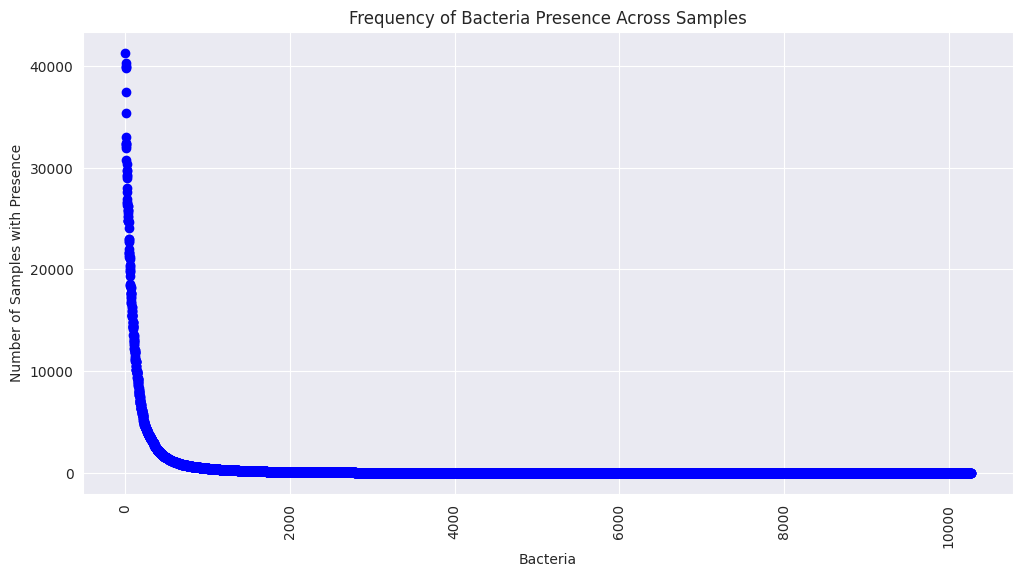

In [28]:
# Count the number of nonzero occurrences per bacteria (column)
df_fixed = df.replace(np.nan, 0.0)
bacteria_presence = (df_fixed != 0).sum()

# Sort from most frequent to least frequent
bacteria_presence = bacteria_presence.sort_values(ascending=False)
# drop third one cuz sample label
bacteria_presence = bacteria_presence[bacteria_presence.index != "sample_id"]
# # Plot the data
plt.figure(figsize=(12, 6))
plt.scatter(x=np.array([i for i in range(bacteria_presence.shape[0])]), y=bacteria_presence.values, color='blue')
plt.xticks(rotation=90)
plt.xlabel('Bacteria')
plt.ylabel('Number of Samples with Presence')
plt.title('Frequency of Bacteria Presence Across Samples')
plt.show()

Number of bacteria species covering 97% of data: 1564


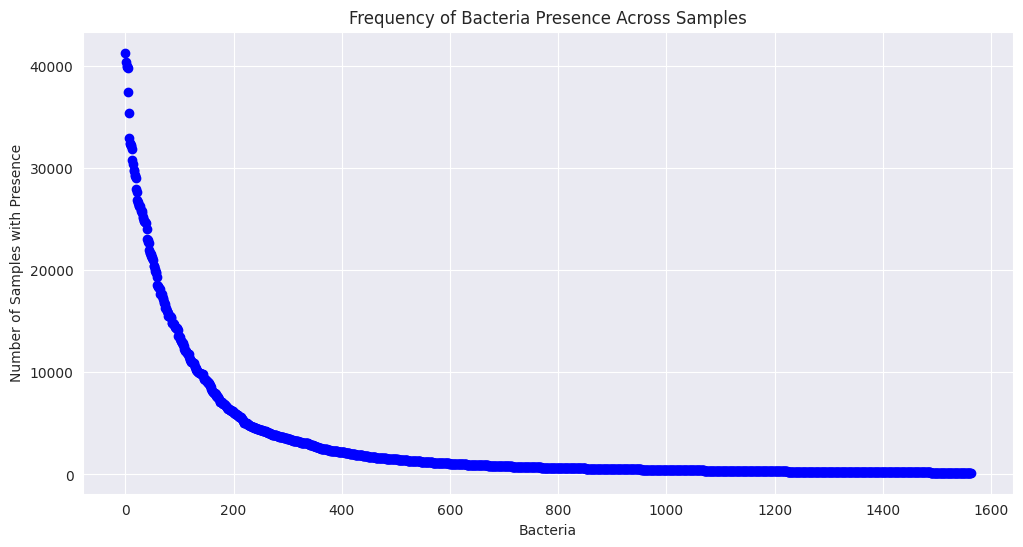

In [29]:
# Compute cumulative sum and find the number of species covering 97% of occurrences
cumulative_sum = bacteria_presence.cumsum()
total_sum = bacteria_presence.sum()
top_97_species = (cumulative_sum / total_sum <= 0.97).sum()
print(f'Number of bacteria species covering 97% of data: {top_97_species}')

# Plot the data
smaller_table = bacteria_presence[:top_97_species]
plt.figure(figsize=(12, 6))
plt.scatter(x=np.array([i for i in range(smaller_table.shape[0])]), y=smaller_table.values, color='blue')
plt.xlabel('Bacteria')
plt.ylabel('Number of Samples with Presence')
plt.title('Frequency of Bacteria Presence Across Samples')
plt.show()

In [30]:
df_small = df_fixed[bacteria_presence[:512].index]
total_cells = df_small.size
nonzero_cells = (df_small != 0).sum().sum()
table_populated_percentage = (nonzero_cells / total_cells) * 100
print(f'Percentage of the entire table populated with data: {table_populated_percentage:.2f}%')

Percentage of the entire table populated with data: 17.23%


In [17]:
df.columns

Index(['Sample',
       'sk__Archaea;k__;p__Euryarchaeota;c__Methanobacteria;o__Methanobacteriales;f__Methanobacteriaceae;g__Methanobrevibacter',
       'sk__Archaea;k__;p__Euryarchaeota;c__Methanobacteria;o__Methanobacteriales;f__Methanobacteriaceae;g__Methanobrevibacter;s__Methanobrevibacter_smithii',
       'sk__Archaea;k__;p__Euryarchaeota;c__Methanomicrobia;o__Methanomicrobiales',
       'sk__Archaea;k__;p__Euryarchaeota;c__Thermoplasmata;o__Methanomassiliicoccales',
       'sk__Archaea;k__;p__Euryarchaeota;c__Thermoplasmata;o__Methanomassiliicoccales;f__Methanomassiliicoccaceae;g__Candidatus_Methanoplasma',
       'sk__Bacteria', 'sk__Bacteria;k__;p__Actinobacteria',
       'sk__Bacteria;k__;p__Actinobacteria;c__Acidimicrobiia;o__Acidimicrobiales;f__Ilumatobacteraceae',
       'sk__Bacteria;k__;p__Actinobacteria;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinomyces',
       ...
       'sk__Bacteria;k__;p__Firmicutes;c__Clostridia;o__Clostridiales;f__Ruminococcac

In [19]:
(df.columns == 'sk__Bacteria;k__;p__Tenericutes;c__Mollicutes;o__Anaeroplasmatales;f__Anaeroplasmataceae;g__Anaeroplasma').sum()

np.int64(1)